In [ ]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras import regularizers
import albumentations as A
from collections import Counter
from tensorflow.keras.regularizers import l2
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
!pip install opendatasets
import opendatasets as od
import pandas

od.download( "https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000/data")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: marpuravikumar
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000


100%|██████████| 5.20G/5.20G [00:32<00:00, 171MB/s]


# Load the data


In [ ]:
data = pd.read_csv('/content/skin-cancer-mnist-ham10000/hmnist_28_28_RGB.csv')
data

,pixel0000,pixel0001,pixel0002,pixel0003,pixel0004,pixel0005,pixel0006,pixel0007,pixel0008,pixel0009,...,pixel2343,pixel2344,pixel2345,pixel2346,pixel2347,pixel2348,pixel2349,pixel2350,pixel2351,label
0,192,153,193,195,155,192,197,154,185,202,...,173,124,138,183,147,166,185,154,177,2
1,25,14,30,68,48,75,123,93,126,158,...,60,39,55,25,14,28,25,14,27,2
2,192,138,153,200,145,163,201,142,160,206,...,167,129,143,159,124,142,136,104,117,2
3,38,19,30,95,59,72,143,103,119,171,...,44,26,36,25,12,17,25,12,15,2
4,158,113,139,194,144,174,215,162,191,225,...,209,166,185,172,135,149,109,78,92,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10010,183,165,181,182,165,180,184,166,182,188,...,208,185,187,208,186,186,206,187,189,0
10011,2,3,1,38,33,32,121,104,103,132,...,96,79,76,24,23,21,3,4,1,0
10012,132,118,118,167,149,149,175,156,160,184,...,204,181,178,181,159,153,172,151,145,0
10013,160,124,146,164,131,152,167,127,146,169,...,185,162,167,184,157,166,185,162,172,0


# Split data into features and labels


In [ ]:
x = data.drop(columns=['label'], axis=1)
y = data['label']



# Print initial class distribution


In [ ]:
# Print initial class distribution
print("Initial class distribution in complete dataset:")
print(y.value_counts().sort_index())
print("\nTotal samples:", len(y))

Initial class distribution in complete dataset:
label
0     327
1     514
2    1099
3     115
4    6705
5     142
6    1113
Name: count, dtype: int64

Total samples: 10015


# Split the data


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42, stratify=y_train)


# Print class distribution after splitting


In [ ]:
print("\nClass distribution after splitting:")
print("Training set distribution:")
print(y_train.value_counts().sort_index())
print("\nValidation set distribution:")
print(y_val.value_counts().sort_index())
print("\nTest set distribution:")
print(y_test.value_counts().sort_index())


Class distribution after splitting:
Training set distribution:
label
0     209
1     329
2     703
3      74
4    4291
5      91
6     712
Name: count, dtype: int64

Validation set distribution:
label
0      53
1      82
2     176
3      18
4    1073
5      23
6     178
Name: count, dtype: int64

Test set distribution:
label
0      65
1     103
2     220
3      23
4    1341
5      28
6     223
Name: count, dtype: int64


# Reshape the training data to image format


In [ ]:
x_train_reshaped = x_train.values.reshape(-1, 28, 28, 3)
x_val_reshaped = x_val.values.reshape(-1, 28, 28, 3)
x_test_reshaped = x_test.values.reshape(-1, 28, 28, 3)

# Data Augmentation Pipeline


In [ ]:
def create_augmentation_pipeline():
    transform = A.Compose([
        A.Rotate(limit=30, p=0.7),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.OneOf([
            A.GaussNoise(p=1),
            A.MultiplicativeNoise(p=1),
        ], p=0.2),
        A.OneOf([
            A.MotionBlur(p=1),
            A.MedianBlur(blur_limit=3, p=1),
            A.GaussianBlur(blur_limit=3, p=1),
        ], p=0.2),
        A.ColorJitter(
            brightness=0.2,
            contrast=0.2,
            saturation=0.2,
            hue=0.1,
            p=0.7
        ),
    ])
    return transform

# Helper functions to reshape data
def reshape_to_image(flat_data):
    if isinstance(flat_data, pd.DataFrame):
        flat_data = flat_data.values
    return flat_data.reshape(-1, 28, 28, 3)

def reshape_to_flat(image_data):
    return image_data.reshape(image_data.shape[0], -1)

# Augment minority classes


In [ ]:

# Augment minority classes
def augment_minority_classes(x_train, y_train, target_samples=None):
    class_counts = Counter(y_train)
    if target_samples is None:
        target_samples = max(class_counts.values())

    x_images = reshape_to_image(x_train)
    if x_images.max() <= 1.0:
        x_images = (x_images * 255).astype(np.uint8)

    transform = create_augmentation_pipeline()
    augmented_images, augmented_labels = [], []

    for class_label in class_counts:
        class_indices = np.where(y_train == class_label)[0]
        class_images = x_images[class_indices]

        n_samples = len(class_images)
        if n_samples < target_samples:
            n_augment = target_samples - n_samples

            for i in range(n_augment):
                idx = i % n_samples
                image = class_images[idx].astype(np.uint8)

                augmented = transform(image=image)
                augmented_image = augmented['image']

                augmented_images.append(augmented_image)
                augmented_labels.append(class_label)

    if augmented_images:
        augmented_images = np.array(augmented_images)
        x_aug = np.vstack([x_train.values if isinstance(x_train, pd.DataFrame) else x_train,
                          reshape_to_flat(augmented_images)])
        y_aug = np.concatenate([y_train, augmented_labels])

        x_aug = pd.DataFrame(x_aug, columns=x_train.columns if isinstance(x_train, pd.DataFrame) else None)
        y_aug = pd.Series(y_aug, name='label')

        return x_aug, y_aug

    return x_train, y_train
# Apply augmentation
x_train_aug, y_train_aug = augment_minority_classes(x_train, y_train)


# Print class distribution after augmentation


In [ ]:

print("\nClass distribution after augmentation:")
print(Counter(y_train_aug))



Class distribution after augmentation:
Counter({4: 4291, 0: 4291, 6: 4291, 2: 4291, 1: 4291, 5: 4291, 3: 4291})


# Reshape augmented data


In [ ]:
x_train_aug = np.array(x_train_aug).reshape(-1, 28, 28, 3)
x_train_aug = x_train_aug / 255.0
x_val_reshaped = x_val_reshaped / 255.0
x_test_reshaped = x_test_reshaped / 255.0

# One-hot encode labels


In [ ]:
y_train_aug = to_categorical(y_train_aug)
y_val = to_categorical(y_val)
y_test = to_categorical(y_test)

# Compute class weights


In [ ]:
y_train_aug_flat = np.argmax(y_train_aug, axis=1)
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_aug_flat), y=y_train_aug_flat)
class_weight_dict = dict(enumerate(class_weights))

# Model architecture


In [ ]:
def create_model(input_shape=(28, 28, 3), num_classes=7):
    model = Sequential([
        Conv2D(64, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(0.001), input_shape=input_shape),
        Conv2D(64, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        Conv2D(128, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(0.001)),
        Conv2D(128, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.3),

        Conv2D(256, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(0.001)),
        Conv2D(256, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.4),

        Flatten(),
        Dense(512, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(0.5),
        Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    return model

# Compile and train the model


In [ ]:
model = create_model()
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ModelCheckpoint('best_model.keras', save_best_only=True, monitor='val_loss'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7)
]

history = model.fit(
    x_train_aug, y_train_aug,
    validation_data=(x_val_reshaped, y_val),
    epochs=1,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


939/939 ━━━━━━━━━━━━━━━━━━━━ 39s 27ms/step - accuracy: 0.2644 - loss: 4.0830 - val_accuracy: 0.3893 - val_loss: 5.0900 - learning_rate: 0.0010


In [ ]:
train_score = model.evaluate(x_train_aug, y_train_aug, verbose=1)
val_score = model.evaluate(x_val_reshaped, y_val, verbose=1)
test_score = model.evaluate(x_test_reshaped, y_test, verbose=1)

print("\nFinal Results:")
print(f"Train Accuracy: {train_score[1]*100:.2f}%")
print(f"Validation Accuracy: {val_score[1]*100:.2f}%")
print(f"Test Accuracy: {test_score[1]*100:.2f}%")

939/939 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.2544 - loss: 6.1149
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3706 - loss: 5.1960
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.3838 - loss: 5.1132

Final Results:
Train Accuracy: 28.75%
Validation Accuracy: 38.93%
Test Accuracy: 39.84%


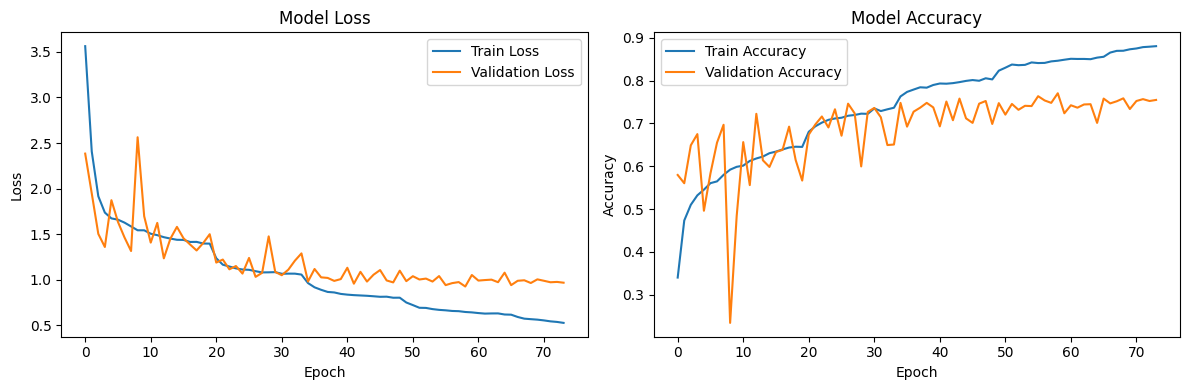

In [ ]:

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Save the final model


In [ ]:
model.save('skin_cancer_mnist.h5')

# Confusion Matrix :
*performance measurement tool used to evaluate the accuracy of a classification model. It compares the predicted labels with the actual labels in a tabular format, allowing us to see how well the model performs for each class.*

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


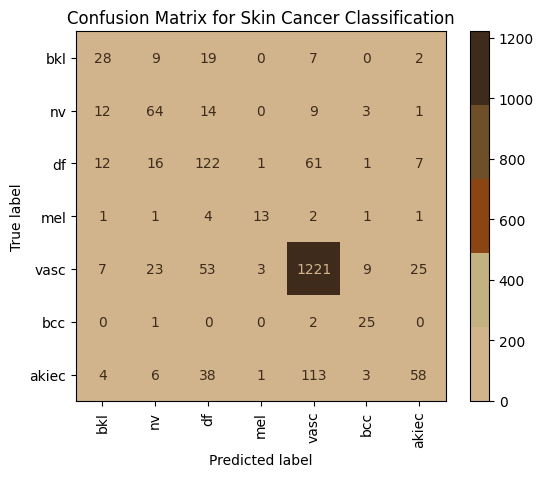

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import ListedColormap
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

beige_brown_palette = ["#D2B48C", "#C2B280", "#8B4513", "#6F4F28", "#3E2B1B"]

metadata_path = '/content/skin-cancer-mnist-ham10000/HAM10000_metadata.csv'
df = pd.read_csv(metadata_path)

class_labels = df['dx'].unique()

predictions = model.predict(x_test_reshaped)
y_pred_classes = np.argmax(predictions, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_test_classes, y_pred_classes)
cmap = ListedColormap(beige_brown_palette)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap=cmap, xticks_rotation='vertical')

plt.title('Confusion Matrix for Skin Cancer Classification')
plt.show()


# Precision :
*Precision measures the accuracy of positive predictions. It tells us, of all the cases the model predicted as positive, how many were actually positive.*
# Recall:
*Recall measures how well the model detects positive cases. It tells us, of all the actual positive cases, how many were correctly predicted by the model.*
# F1-Score:
*F1-Score is the harmonic mean of precision and recall. It is a balanced metric that considers both precision and recall.*

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


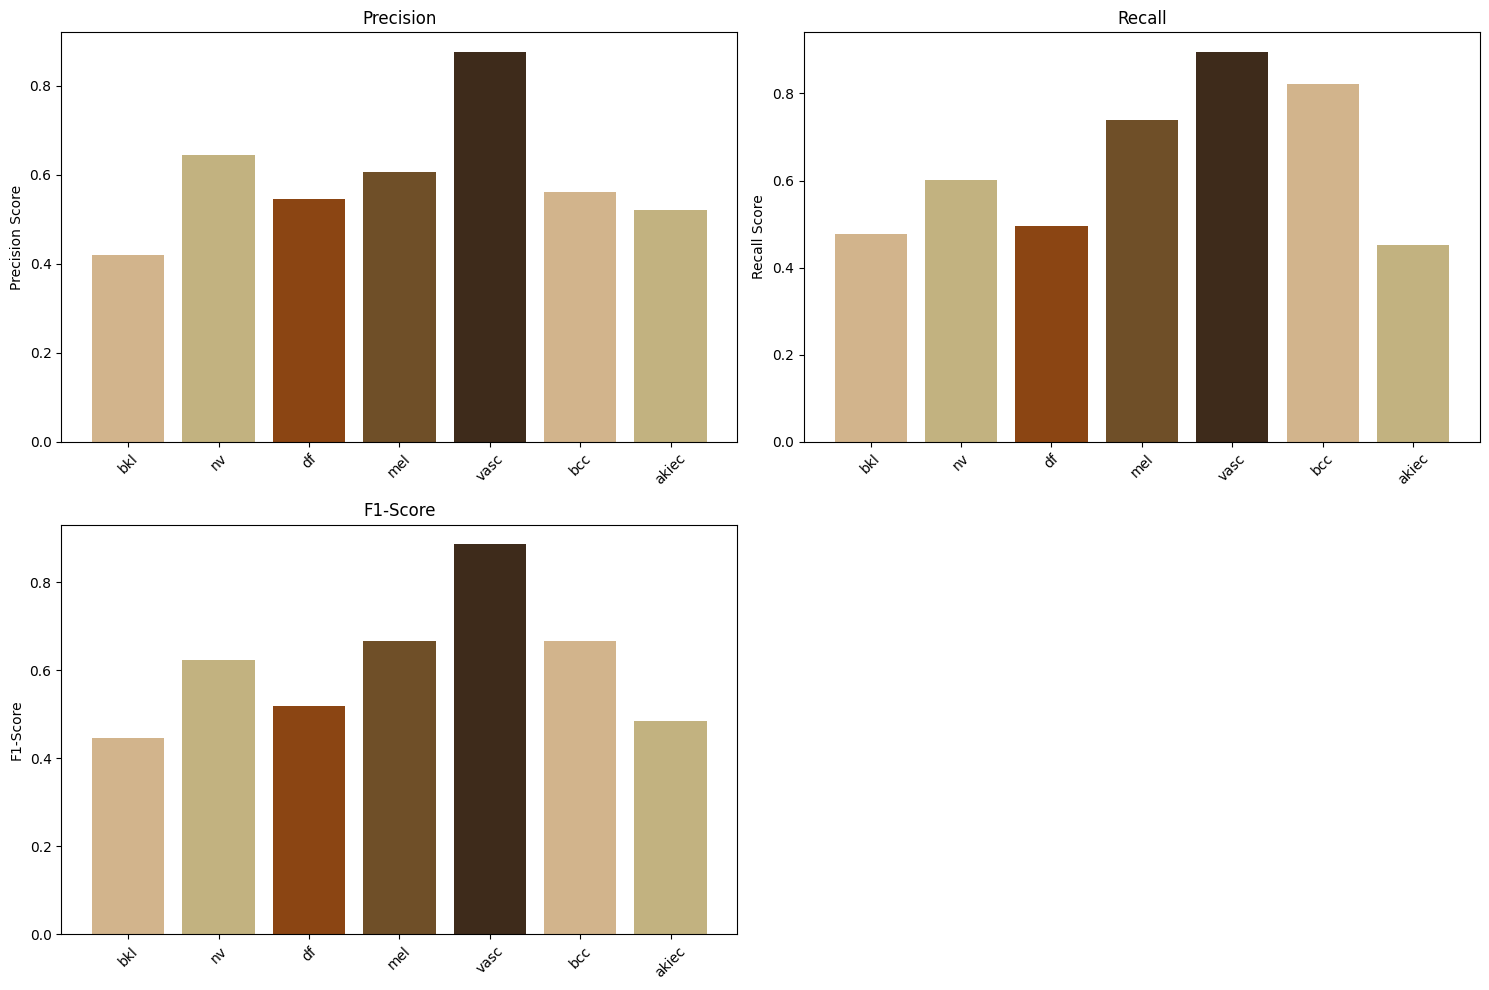

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score

beige_brown_palette = ["#D2B48C", "#C2B280", "#8B4513", "#6F4F28", "#3E2B1B"]

metadata_path = '/content/skin-cancer-mnist-ham10000/HAM10000_metadata.csv'
df = pd.read_csv(metadata_path)

class_labels = df['dx'].unique()

predictions = model.predict(x_test_reshaped)
y_pred_classes = np.argmax(predictions, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

precision = precision_score(y_test_classes, y_pred_classes, average=None)
recall = recall_score(y_test_classes, y_pred_classes, average=None)
f1 = f1_score(y_test_classes, y_pred_classes, average=None)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].bar(class_labels, precision, color=beige_brown_palette[:len(class_labels)])
axes[0, 0].set_title('Precision')
axes[0, 0].set_ylabel('Precision Score')
axes[0, 0].tick_params(axis='x', rotation=45)

axes[0, 1].bar(class_labels, recall, color=beige_brown_palette[:len(class_labels)])
axes[0, 1].set_title('Recall')
axes[0, 1].set_ylabel('Recall Score')
axes[0, 1].tick_params(axis='x', rotation=45)

axes[1, 0].bar(class_labels, f1, color=beige_brown_palette[:len(class_labels)])
axes[1, 0].set_title('F1-Score')
axes[1, 0].set_ylabel('F1-Score')
axes[1, 0].tick_params(axis='x', rotation=45)

axes[1, 1].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

In [ ]:
from tensorflow.keras.models import load_model
model = load_model('skin_cancer_mnist.h5')

In [ ]:
img_path = '/content/download.jpg'  # Replace with the actual path
img = image.load_img(img_path, target_size=(28, 28))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0  # Normalize the image

In [ ]:
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction[0])

# Get the class labelsskin-cancer
metadata_path = '/content/skin-cancer-mnist-ham10000/HAM10000_metadata.csv'
df = pd.read_csv(metadata_path)
class_labels = df['dx'].unique()

print("Predicted class:", class_labels[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted class: bcc
